In [1]:
import torch 
import torch.nn as nn
import numpy as np
from pathlib import Path
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from src.data.tabular import split_data
from src.models.Autoencoder import Autoencoder

In [2]:
digits = load_digits()
X = digits.data
X = StandardScaler().fit_transform(X)  
y = digits.target
X_train, X_val, X_test, y_train, y_val, y_test, encoder = split_data(X, y)
X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor   = torch.from_numpy(X_val).float()
X_test_tensor  = torch.from_numpy(X_test).float()

X_train_val_tensor = torch.cat([X_train_tensor, X_val_tensor], dim=0)
X_train_val = X_train_val_tensor.detach().cpu().numpy()
print("split shape",X_train.shape, X_val.shape, X_test.shape)

n_features = X_train.shape[1]

split shape (1078, 64) (360, 64) (359, 64)


In [3]:
import torch
from src.hpo.autoencoder_hpo import create_study

X_train_tensor = torch.randn(8, 4)
X_val_tensor = torch.randn(4, 4)

study = create_study(
    X_train_tensor,
    X_val_tensor,
    n_epochs=2,
    bottleneck_dim=2,
    n_trials=20,
    study_name="autoencoder_HPO_digits_analysis"
)

print(len(study.trials))
print(study.best_value)
print(study.best_params)

h:\Course contents FAU\semester 5\Thesis\final Project\LatentDimAnalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-07 20:59:05,500] A new study created in memory with name: autoencoder_HPO_digits_analysis
Best trial: 8. Best value: 0.730231:  40%|████      | 8/20 [00:03<00:06,  1.92it/s]

[I 2026-09-07 20:59:08,844] Trial 0 finished with value: 0.8603049516677856 and parameters: {'lr': 0.0001329291894316216, 'depth': 3, 'activation': 'ReLU'}. Best is trial 0 with value: 0.8603049516677856.
[I 2026-09-07 20:59:08,907] Trial 1 finished with value: 0.8654546737670898 and parameters: {'lr': 1.493656855461762e-05, 'depth': 3, 'activation': 'Tanh'}. Best is trial 0 with value: 0.8603049516677856.
[I 2026-09-07 20:59:08,918] Trial 2 finished with value: 0.7889568209648132 and parameters: {'lr': 0.00314288089084011, 'depth': 1, 'activation': 'Tanh'}. Best is trial 2 with value: 0.7889568209648132.
[I 2026-09-07 20:59:08,928] Trial 3 finished with value: 0.7307183146476746 and parameters: {'lr': 0.00019762189340280086, 'depth': 1, 'activation': 'ReLU'}. Best is trial 3 with value: 0.7307183146476746.
[I 2026-09-07 20:59:08,949] Trial 4 finished with value: 0.831360399723053 and parameters: {'lr': 0.00023345864076016249, 'depth': 3, 'activation': 'GELU'}. Best is trial 3 with val

Best trial: 14. Best value: 0.72607:  85%|████████▌ | 17/20 [00:03<00:00,  8.31it/s]

[I 2026-09-07 20:59:09,035] Trial 9 pruned. 
[I 2026-09-07 20:59:09,059] Trial 10 finished with value: 0.7562969923019409 and parameters: {'lr': 0.0075285982833986536, 'depth': 2, 'activation': 'LeakyReLU'}. Best is trial 8 with value: 0.7302310466766357.
[I 2026-09-07 20:59:09,079] Trial 11 pruned. 
[I 2026-09-07 20:59:09,103] Trial 12 finished with value: 0.73103266954422 and parameters: {'lr': 4.3412642890893885e-05, 'depth': 1, 'activation': 'ReLU'}. Best is trial 8 with value: 0.7302310466766357.
[I 2026-09-07 20:59:09,125] Trial 13 pruned. 
[I 2026-09-07 20:59:09,147] Trial 14 finished with value: 0.7260696887969971 and parameters: {'lr': 0.002482076244951993, 'depth': 1, 'activation': 'ReLU'}. Best is trial 14 with value: 0.7260696887969971.
[I 2026-09-07 20:59:09,168] Trial 15 pruned. 
[I 2026-09-07 20:59:09,184] Trial 16 finished with value: 0.7267669439315796 and parameters: {'lr': 0.0021388278317532993, 'depth': 1, 'activation': 'ReLU'}. Best is trial 14 with value: 0.726069

Best trial: 19. Best value: 0.722932: 100%|██████████| 20/20 [00:03<00:00,  5.35it/s]

[I 2026-09-07 20:59:09,217] Trial 18 pruned. 
[I 2026-09-07 20:59:09,237] Trial 19 finished with value: 0.7229317426681519 and parameters: {'lr': 0.004029258589451388, 'depth': 1, 'activation': 'ReLU'}. Best is trial 19 with value: 0.7229317426681519.
20
0.7229317426681519
{'lr': 0.004029258589451388, 'depth': 1, 'activation': 'ReLU'}


In [4]:
from sklearn.decomposition import PCA
from src.hpo.hidden_dims import build_hidden_dims_geo, build_hidden_dims_static
from src.training.train import train_final_model

best_params = study.best_params
activations = {
    'ReLU': nn.ReLU,
    'LeakyReLU': nn.LeakyReLU,
    'GELU': nn.GELU,
    'Tanh': nn.Tanh
}

best_activation = activations.get(best_params.get('activation', 'ReLU'), nn.ReLU)
best_depth = best_params['depth']
best_lr = best_params['lr']

input_dim = X_train_val_tensor.shape[1]
bottleneck_range = [1, 2, 4, 8, 16, 32, 62]
epochs = 400
ae_errors = []
pca_errors = []

for k in bottleneck_range:

    #final_hidden_dims = build_hidden_dims_geo(input_dim, k, best_depth)
    final_hidden_dims = build_hidden_dims_static(input_dim, depth=best_depth)

    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_train_val)
    X_recon_pca = pca.inverse_transform(X_reduced)
    pca_errors.append(np.mean((X_train_val - X_recon_pca) ** 2))

    final_model = Autoencoder(
        n_features=input_dim,
        bottleneck_dim=k,
        non_linear=True,
        non_linear_function=best_activation,
        hidden_dims_list=final_hidden_dims
    )

    train_loss, test_loss = train_final_model(
        final_model=final_model,
        X_train_val_tensor=X_train_val_tensor,
        X_test_tensor=X_test_tensor, 
        best_params=best_params, 
        epochs=400
    )

    ae_errors.append(train_loss)
    print(f"k={k:>3} PCA={pca_errors[-1]:.4f}  Non Linear AE={ae_errors[-1]:.4f}")

k=  1 PCA=0.8499  Non Linear AE=0.5920
k=  2 PCA=0.7585  Non Linear AE=0.3352
k=  4 PCA=0.6153  Non Linear AE=0.1983
k=  8 PCA=0.4561  Non Linear AE=0.1121
k= 16 PCA=0.2587  Non Linear AE=0.0565
k= 32 PCA=0.0855  Non Linear AE=0.0265
k= 62 PCA=0.0000  Non Linear AE=0.0125


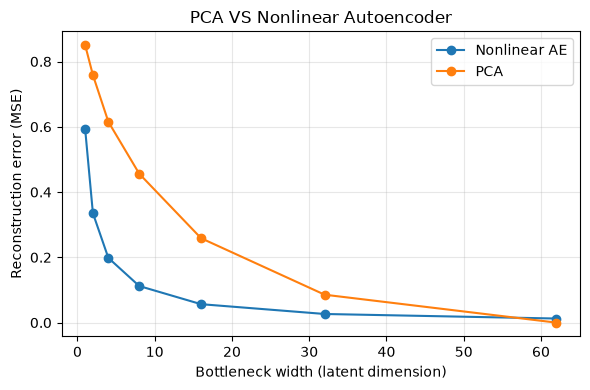

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, ae_errors, marker="o", label="Nonlinear AE")
plt.plot(bottleneck_range, pca_errors, marker="o", label="PCA")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA VS Nonlinear Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()